In [10]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import BaggingClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.datasets import make_classification
import seaborn as sns
from joblib import Parallel, delayed

# wahre Funktion, die die Klassen(n_class=2) generiert
def true_function(X,seed):
    return (np.sin(X[:, 0]) + 0.5 * np.cos(2 * X[:, 1])) > 0

# Daten generieren, die die generierende Funktion nicht widerspiegeln
def generate_biased_data(n_samples, seed):
    np.random.seed(seed)
    X, _ = make_classification(n_samples=n_samples, n_features=2, n_informative=2, n_redundant=0, random_state=seed)
    y = np.random.choice([0, 1], size=n_samples) 
    return X, y

# Gewichtetes Bootstrapping basierend auf der wahren Verteilung
def generate_weighted_bootstrap_samples(X, y, weights, seed):
    np.random.seed(seed)
    n_samples = len(X)
    indices = np.random.choice(np.arange(n_samples), size=n_samples, replace=True, p=weights)
    return X[indices], y[indices]

# Funktion zum Trainieren eines einzelnen Modells
def train_single_model(X, y, weights, seed, model_index):
    X_boot, y_boot = generate_weighted_bootstrap_samples(X, y, weights, seed + model_index)
    model = DecisionTreeClassifier(random_state=seed + model_index)
    model.fit(X_boot, y_boot)
    return model

In [11]:
seed = 45
n_train = 1_000
n_test = 1000
B = 1_000

# Daten generieren
X, y = generate_biased_data(n_samples=n_train, seed=seed)

# Erstellen der Gewichtung basierend auf der wahren Funktion mit Rauschen
y_true = true_function(X,seed).astype(int)
weights = np.exp(-0.5 * ((y - y_true) / np.std(y_true))**2)
weights /= weights.sum()  


Weighted Bootstrapping - Accuracy: 0.90, Precision: 0.87, Recall: 0.92, F1 Score: 0.89
Unweighted Bootstrapping - Accuracy: 0.49, Precision: 0.46, Recall: 0.50, F1 Score: 0.48


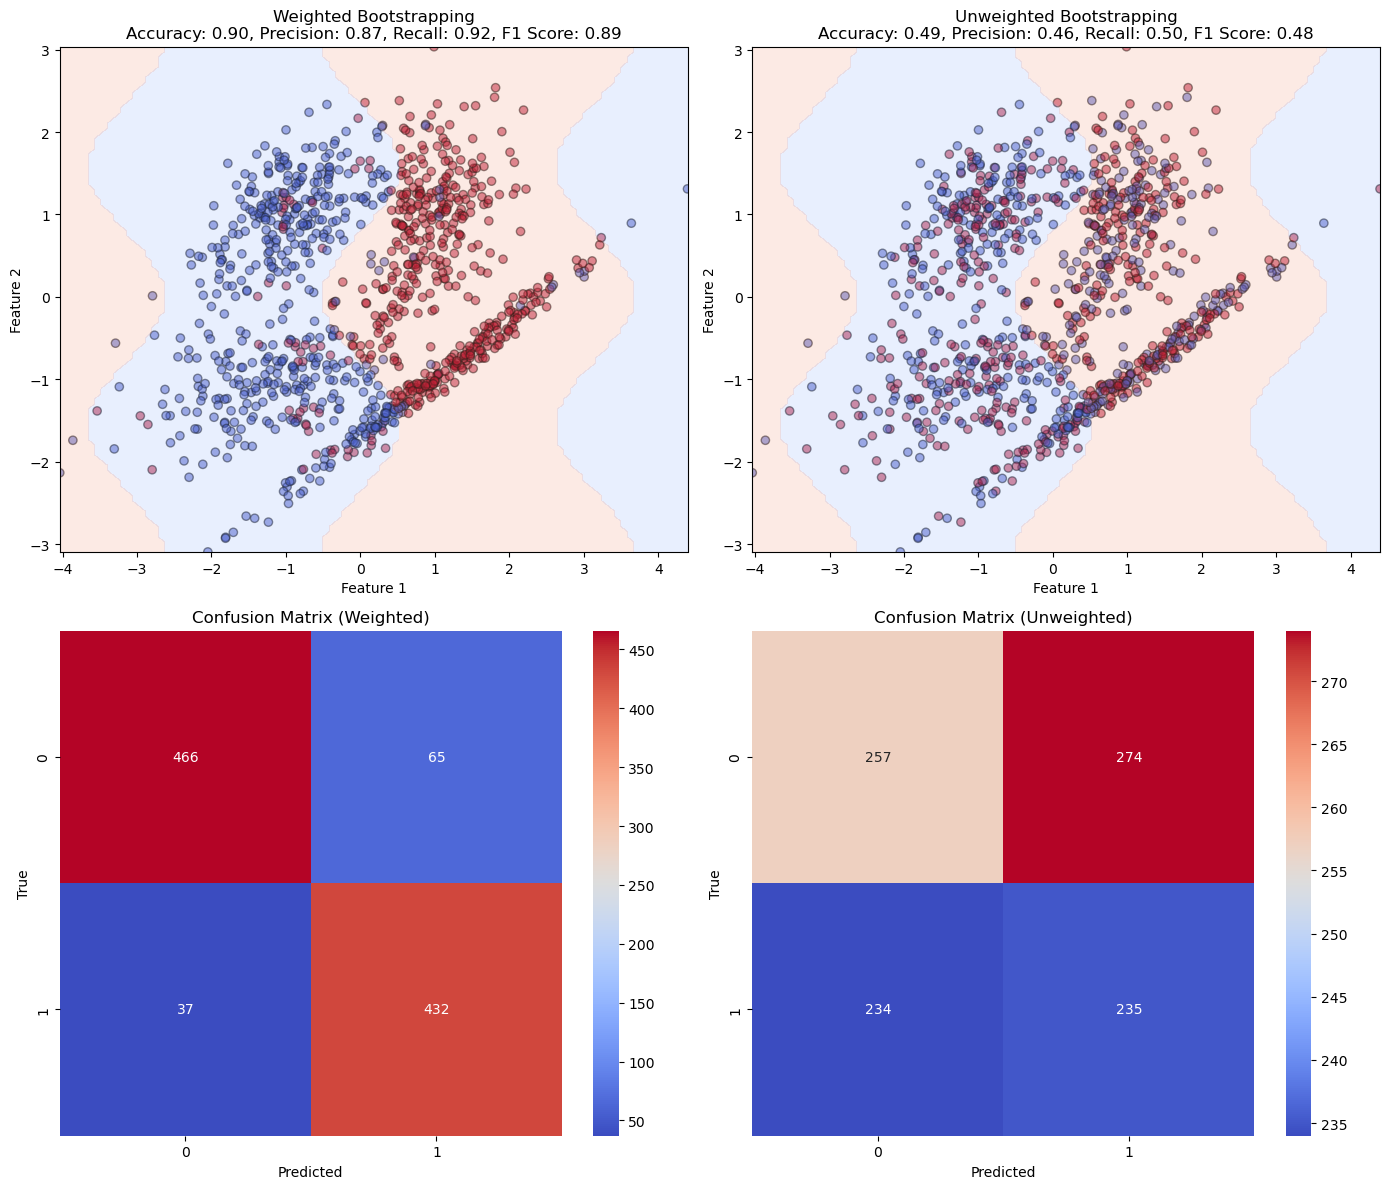

In [13]:
# Ungewichteter BaggingClassifier
unweighted_bagging = BaggingClassifier(estimator=DecisionTreeClassifier(), n_estimators=B, bootstrap=True,random_state=seed,n_jobs=-1)
unweighted_bagging.fit(X, y)

# Gewichteter BaggingClassifier durch manuelles Bootstrapping mit Parallelisierung
weighted_models = Parallel(n_jobs=-1)(delayed(train_single_model)(X, y, weights, seed, i) for i in range(B))

def predict_ensemble(models, X):
    predictions = np.array([model.predict(X) for model in models])
    return np.apply_along_axis(lambda x: np.argmax(np.bincount(x)), axis=0, arr=predictions)

# Vorhersagen
X_test, y_test = make_classification(n_samples=n_test, n_features=2, n_informative=2, n_redundant=0, random_state=seed)
y_true_test = true_function(X_test,seed).astype(int)
y_pred_weighted = predict_ensemble(weighted_models, X_test)
y_pred_unweighted = unweighted_bagging.predict(X_test)

# Auswertung der Metriken
def evaluate_model(y_true, y_pred):
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    conf_matrix = confusion_matrix(y_true, y_pred)
    return accuracy, precision, recall, f1, conf_matrix

metrics_weighted = evaluate_model(y_true_test, y_pred_weighted)
metrics_unweighted = evaluate_model(y_true_test, y_pred_unweighted)

print(f"Weighted Bootstrapping - Accuracy: {metrics_weighted[0]:.2f}, Precision: {metrics_weighted[1]:.2f}, Recall: {metrics_weighted[2]:.2f}, F1 Score: {metrics_weighted[3]:.2f}")
print(f"Unweighted Bootstrapping - Accuracy: {metrics_unweighted[0]:.2f}, Precision: {metrics_unweighted[1]:.2f}, Recall: {metrics_unweighted[2]:.2f}, F1 Score: {metrics_unweighted[3]:.2f}")

# Wahre Funktion berechnen
xx, yy = np.meshgrid(np.linspace(X_test[:, 0].min(), X_test[:, 0].max(), 100),
                     np.linspace(X_test[:, 1].min(), X_test[:, 1].max(), 100))
Z = true_function(np.c_[xx.ravel(), yy.ravel()],seed)
Z = Z.reshape(xx.shape)

# Ergebnisse visualisieren
plt.figure(figsize=(14, 12))

plt.subplot(2, 2, 1)
plt.scatter(X_test[:, 0], X_test[:, 1], c=y_pred_weighted, cmap='coolwarm', alpha=0.5, edgecolor='k')
plt.contourf(xx, yy, Z, alpha=0.2, cmap='coolwarm')
plt.title(f'Weighted Bootstrapping\nAccuracy: {metrics_weighted[0]:.2f}, Precision: {metrics_weighted[1]:.2f}, Recall: {metrics_weighted[2]:.2f}, F1 Score: {metrics_weighted[3]:.2f}')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')

plt.subplot(2, 2, 2)
plt.scatter(X_test[:, 0], X_test[:, 1], c=y_pred_unweighted, cmap='coolwarm', alpha=0.5, edgecolor='k')
plt.contourf(xx, yy, Z, alpha=0.2, cmap='coolwarm')
plt.title(f'Unweighted Bootstrapping\nAccuracy: {metrics_unweighted[0]:.2f}, Precision: {metrics_unweighted[1]:.2f}, Recall: {metrics_unweighted[2]:.2f}, F1 Score: {metrics_unweighted[3]:.2f}')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')

plt.subplot(2, 2, 3)
sns.heatmap(metrics_weighted[4], annot=True, fmt='d', cmap='coolwarm')
plt.title('Confusion Matrix (Weighted)')
plt.xlabel('Predicted')
plt.ylabel('True')

plt.subplot(2, 2, 4)
sns.heatmap(metrics_unweighted[4], annot=True, fmt='d', cmap='coolwarm')
plt.title('Confusion Matrix (Unweighted)')
plt.xlabel('Predicted')
plt.ylabel('True')

plt.tight_layout()
plt.show()
